In [7]:
import numpy as np
import networkx as nx
import pandas as pd
import pickle
import random
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

from dtw import *
from copy import deepcopy

import numpy as np
from concurrent.futures import ProcessPoolExecutor
from copy import deepcopy
import os


def save_dict_to_pickle(dictionary, filename):
    import os
    #print(f'Saving the dictionary to {filename}...')
    # Extract the directory path from the filename
    directory = os.path.dirname(filename)
    
    # Create the directory if it doesn't exist
    if not os.path.exists(directory):
        os.makedirs(directory)

    # Save the dictionary to the pickle file
    with open(filename, 'wb') as file:
        pickle.dump(dictionary, file)
    #print('Saving complete...')

def load_dict_from_pickle(filename):
    with open(filename, 'rb') as file:
        loaded_dict = pickle.load(file)
    return loaded_dict


# Procedure here as follow:
# for each patient in the test set, create new set for diagnoses where we identify a random location, 
# remove item at that location, and keep a record of that location in another data structure.

def remove_random_item(L):
    '''get 
        - removed item, 
        - its index, 
        - the new list after removal
        - LHS_item: left neighbor
        - RHS_item: right neighbor'''
    # Generate a random index
    #print(L)
    random_index = random.randint(1, len(L) - 2)
    LHS = random_index - 1
    RHS = random_index + 1
    
    LHS_item = L[LHS]    
    RHS_item = L[RHS]    

    # Remove the item at the random index and #print it
    removed_item = L.pop(random_index)
    
    return {'removed_item': removed_item, 'loc': random_index, 'List': L, 'L_item': LHS_item, 'R_item': RHS_item}

# Example list
my_list = [1, 2, 3, 4, 5]
remove_random_item(my_list)

{'removed_item': 3, 'loc': 2, 'List': [1, 2, 4, 5], 'L_item': 2, 'R_item': 4}

# Dynamic Time Wrapping (DTW)

In [8]:
def maps(l1, l2):
    '''creates a dictionary where the unique elements of l1 become keys, 
    and their corresponding values are lists of elements from l2 
    THAT SHARE THE SAME INDEX...'''
    
    D = {}
    for i in range(len(l1)):
        if l1[i] not in D.keys():
            D[l1[i]] = []

        D[l1[i]].append(l2[i])

    return D


def viz(Q, T, ind1, ind2, fname):
    # Convert to numpy arrays for ease of indexing
    Q = np.array(Q)
    T = np.array(T)

    # Plot the query and template signals with alignment lines
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(Q)), Q, 'r-', label='Query Signal')
    plt.plot(range(len(T)), T, 'b-', label='Template Signal')

    # Plot the alignment lines
    for i, j in zip(ind1, ind2):
        plt.plot([i, j], [Q[i], T[j]], 'k-', alpha=0.5)

    plt.scatter(ind1, Q[ind1], color='red')
    plt.scatter(ind2, T[ind2], color='blue')

    # Labeling the plot
    plt.xlabel('Index')
    plt.ylabel('Signal Value')
    plt.legend()
    plt.title('DTW Alignment')

    plt.tight_layout()
    # plt.savefig(fname, dpi = 300)
    plt.show()


def compute_missing_ranges(M, D):
    """
    Compute the missing ranges in M based on D.

    Parameters:
    - M: Dictionary where keys are tuples representing pairs of indices and values are lists to store ranges.
    - D: Dictionary where keys are indices and values are lists of indices from another list.

    Returns:
    - Updated M dictionary with computed ranges appended to each key's list.
    """

    for p in M:

        start = min(D[p[0]]) + 1
        end = max(D[p[1]])
        M[p].extend([r for r in range(start, end)])

    return M


def dist(x, y):
    if x == y:
        return 0
    else:
        return 1


### Visit-based simulation

In [9]:
def read_df(myPath):
    return pd.read_csv(myPath)

def get_dictionary(df, id1, id2):
    grouped_df = df.groupby(id1)[id2].agg(list)
    return grouped_df.to_dict()

# Step 1: Convert each ICD9_CODE to 3 digits format by replacing the original column
def convert_to_3digit(icd9_code):
    if pd.isna(icd9_code):
        return None
    else:
        return str(icd9_code)[:3]

def converting_dictionary(D, ch):
    '''reduce the icd code according to the type'''
    if ch == 'D':
        return {d: [f'{ch}_{str(e)[:3]}' for e in D[d]] for d in D}
    elif ch == 'R':
        return {d: [f'{ch}_{str(e)[:2]}' for e in D[d]] for d in D}
    elif ch =='M':
        return {d: [f'{ch}_{e}' for e in D[d]] for d in D}


MIMIC_resources = '/lustre/home/almusawiaf/PhD_Projects/MIMIC_resources'
df_diagnosis  = read_df(f'{MIMIC_resources}/DIAGNOSES_ICD.csv')

df_diagnosis.dropna(subset=['ICD9_CODE'])
df = df_diagnosis


# Apply the conversion directly to the ICD9_CODE column
df['ICD9_CODE'] = df['ICD9_CODE'].apply(convert_to_3digit)

# Step 2: Count frequencies of the new 3-digit ICD9 codes
icd9_frequencies = df['ICD9_CODE'].value_counts()

# Step 3: Remove rows by keeping top 75% of ICD9 codes based on frequency
cumulative_percent = icd9_frequencies.cumsum() / icd9_frequencies.sum()
top_75_percent_icd9 = cumulative_percent[cumulative_percent <= 0.25].index

# Filter the DataFrame to keep only the top 75% ICD9 codes
df_filtered = df[df['ICD9_CODE'].isin(top_75_percent_icd9)]

# Display the filtered DataFrame
print(df_filtered)

admission_diagnoses0   = get_dictionary(df_filtered, 'HADM_ID', 'ICD9_CODE')
admission_diagnoses   = converting_dictionary(admission_diagnoses0, 'D')

        ROW_ID  SUBJECT_ID  HADM_ID  SEQ_NUM ICD9_CODE
5         1302         109   172335      6.0       276
7         1304         109   172335      8.0       276
11        1308         109   172335     12.0       285
12        1309         109   172335     13.0       285
20        1317         109   173633      7.0       285
...        ...         ...      ...      ...       ...
651013  639769       97488   161999     14.0       272
651014  639770       97488   161999     15.0       250
651016  639772       97488   161999     17.0       428
651036  639792       97497   168949      5.0       276
651038  639794       97497   168949      7.0       427

[157942 rows x 5 columns]


In [10]:
print('Deleting records with empty diagnoses...')

Admissions = list(admission_diagnoses.keys())
admisstions_to_delete = []
for adm in Admissions:
    if len(admission_diagnoses[adm]) <=3:
        admisstions_to_delete.append(adm)

Admissions = [adm for adm in Admissions if adm not in admisstions_to_delete]
# ===============================================================================

# # Visit-based simulation
# num_Admissions = 500
# sample_of_Admissions = random.sample(Admissions, num_Admissions)
# train_Admissions, test_Admissions = train_test_split(sample_of_Admissions, test_size=0.2, random_state=42)

train_Admissions, test_Admissions = train_test_split(Admissions, test_size=0.2, random_state=42)


print("Training Data:", len(train_Admissions))
print("Testing Data:", len(test_Admissions))


Deleting records with empty diagnoses...
Training Data: 15816
Testing Data: 3955


In [11]:
len(Admissions)

19771

## Testing

{'removed_item': 'D_250', 'loc': 2, 'List': ['D_414', 'D_250', 'D_272'], 'L_item': 'D_250', 'R_item': 'D_272'}
complete query:  ['D_414', 'D_250', 'D_250', 'D_272']
query:           ['D_414', 'D_250', 'D_272']
template:        ['D_414', 'D_250', 'D_250', 'D_272']
cost:  0.0
query_ind:     [0 1 1 2]
template_ind:  [0 1 2 3]
cost:  0.0
query_ind:     [0 1 1 2]
template_ind:  [0 1 2 3]
----------------------------------------------------------------------------------
mapping:  {0: [0], 1: [1, 2], 2: [3]}
mapping:  {0: [0], 1: [1], 2: [1], 3: [2]}
----------------------------------------------------------------------------------
Updated M: {(1, 2): [2]}
1 2 [2] ['D_250']


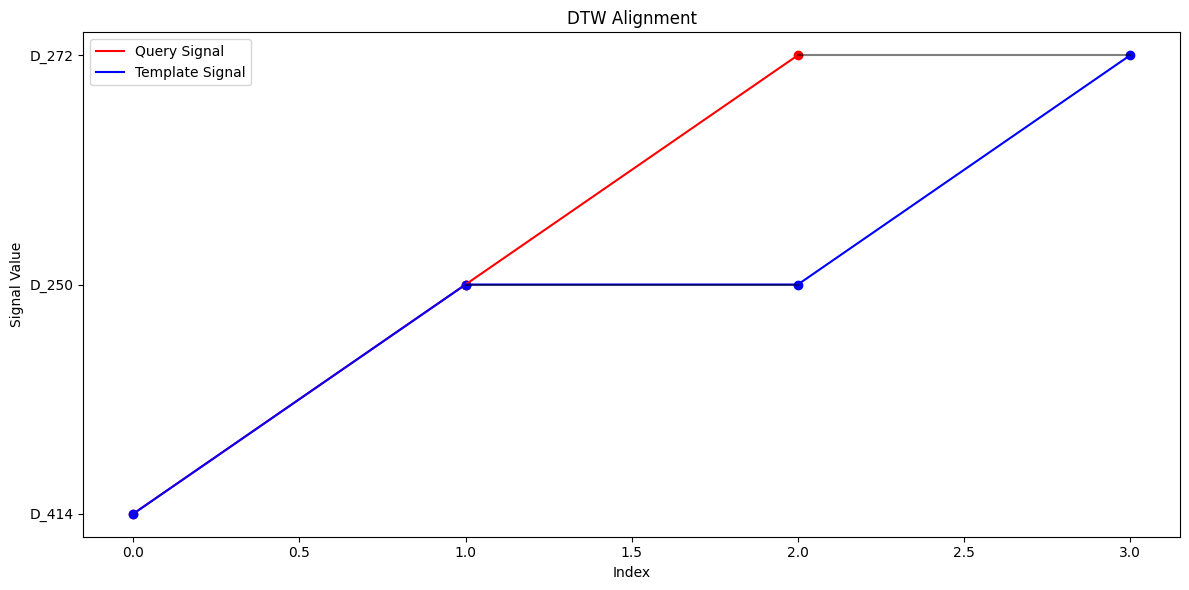

In [12]:
test_A  = random.sample(test_Admissions, 1)[0] 
train_A = random.sample(train_Admissions,1)[0]

complete_query = admission_diagnoses [test_A]
# template       = admission_diagnoses [train_A]

template = complete_query.copy()

partial = remove_random_item(complete_query.copy())
print(partial)
query = partial['List']

print('complete query: ', complete_query)
print('query:          ', query)
print('template:       ', template)

# Find the best match with the canonical recursion formula
alignment = dtw(query, template, dist)

cost, _, _, (query_ind, template_ind) = deepcopy(alignment)
print('cost: ', cost)
print('query_ind:    ', query_ind)
print("template_ind: ", template_ind)

# cost, query_ind, template_ind = alignment.distance, alignment.index1, alignment.index2

print('cost: '        , cost)
print('query_ind:    ', query_ind)
print('template_ind: ', template_ind)
print('----------------------------------------------------------------------------------')

dic_qt = maps(query_ind, template_ind)
print ('mapping: ', dic_qt)

dic_tq = maps(template_ind, query_ind)
print ('mapping: ', dic_tq)

print('----------------------------------------------------------------------------------')

# # Example usage:
left_index  = query.index(partial['L_item'])
right_index = query.index(partial['R_item'])

M_1 = compute_missing_ranges({(left_index, right_index): []}, deepcopy(dic_qt))
print("Updated M:", M_1)
print(left_index, right_index, M_1[(left_index, right_index)], [template[i] for i in M_1[(left_index, right_index)]])

viz(query, template, query_ind, template_ind, 'DTW_Render.png')

In [13]:
Partials = []
Y = []
Results = []

# Preparing the Partial values...
for i_test in test_Admissions:
    complete_query = admission_diagnoses [i_test]
    partial = remove_random_item(complete_query.copy())
    Partials.append(deepcopy(partial))
    Y.append(partial['removed_item'])

In [14]:
def compare_partial_to_complete(partial, train_Admissions, admission_diagnoses, dist):
    query = partial['List']
    one_result = []
    
    for j_train in train_Admissions:
        template = admission_diagnoses[j_train]

        # Find the best match with the canonical recursion formula
        alignment = dtw(query, template, dist)
        cost, query_ind, template_ind = alignment.distance, alignment.index1, alignment.index2

        dic_qt = maps(query_ind, template_ind)

        left_index  = query.index(partial['L_item'])
        right_index = query.index(partial['R_item'])

        M_1 = compute_missing_ranges({(left_index, right_index): []}, deepcopy(dic_qt))
        
        # PL: predicted labels (list), 
        # SC: similarity score.
        PL = [template[k] for k in M_1[(left_index, right_index)]]
        one_result.append({'PL': PL, 'SC': np.exp(-cost)})
    
    return one_result

def parallel_compare_partials(Partials, train_Admissions, admission_diagnoses, dist, max_workers=4):
    Results = []
    
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(compare_partial_to_complete, partial, train_Admissions, admission_diagnoses, dist) for partial in Partials]
        
        for future in futures:
            Results.append(future.result())
    
    Results = np.array(Results)
    return Results


num_cores = os.cpu_count()
print(f"Number of CPU cores available: {num_cores}")

# Example usage
Results = parallel_compare_partials(Partials, train_Admissions, admission_diagnoses, dist, max_workers=num_cores)


Number of CPU cores available: 128


AttributeError: 'tuple' object has no attribute 'distance'

# Majority Voting...

In [ ]:
def majority_voting(Results):
    """
    Perform majority voting on the Results and return the selected items.

    Parameters:
    - Results: A list of dictionaries containing 'PL' (predicted labels) and 'SC' (similarity score).

    Returns:
    - p_Y: A list of selected items based on majority voting.
    """
    p_Y = []

    for R in Results:
        items = []
        freq = {}
        sc = {}
        
        for r in R:  # for each row in Results
            if len(r['PL']) >= 1:
                # if number of predicted labels is one or more
                for pl in r['PL']:
                    if pl not in items:
                        items.append(pl)
                        freq[pl] = 1
                        sc[pl] = [r['SC']]
                    else:
                        freq[pl] += 1
                        sc[pl].append(r['SC'])
        
        MV = {}
        # Now, calculate the majority voting...
        if len(items) >= 1:
            for it in items:
                MV[it] = sum(sc[it])
            selected_item = max(MV, key=MV.get)
        else:
            selected_item = 'D_XXX'

        p_Y.append(selected_item)
    
    return p_Y



def majority_voting_top4(Results):
    """
    Perform majority voting on the Results and return the selected items.

    Parameters:
    - Results: A list of dictionaries containing 'PL' (predicted labels) and 'SC' (similarity score).

    Returns:
    - p_Y: A list of selected items based on majority voting.
    """
    p_Y = []

    for R in Results:
        items = []
        freq = {}
        sc = {}
        
        for r in R:  # for each row in Results
            if len(r['PL']) >= 1:
                # if number of predicted labels is one or more
                for pl in r['PL']:
                    if pl not in items:
                        items.append(pl)
                        freq[pl] = 1
                        sc[pl] = [r['SC']]
                    else:
                        freq[pl] += 1
                        sc[pl].append(r['SC'])
        
        MV = {}
        # Now, calculate the majority voting...
        if len(items) >= 1:
            for it in items:
                MV[it] = sum(sc[it])

            # Sort the dictionary by its values in decreasing order
            sorted_items = sorted(MV.items(), key=lambda item: item[1], reverse=True)

            # Select the top 4 items
            top_4_items = sorted_items[:8]

            # Convert the result back to a dictionary (if needed)
            top_4_dict = dict(top_4_items)

            selected_item = list(top_4_dict.keys())

        else:
            selected_item = ['D_XXX']

        p_Y.append(selected_item)
    
    return p_Y


def calculate_accuracy(true_classes, predicted_classes):
  """Calculates the accuracy of predicted classes compared to true classes.

  Args:
    true_classes: A list of true class labels for each observation.
    predicted_classes: A list of predicted class labels for each observation.

  Returns:
    The accuracy as a float between 0 and 1.
  """

  assert len(true_classes) == len(predicted_classes), "Number of true and predicted classes must match"

  correct_predictions = 0
  total_observations = len(true_classes)

  for true_class, predicted_class in zip(true_classes, predicted_classes):
    if true_class == predicted_class:
      correct_predictions += 1

  accuracy = correct_predictions / total_observations
  return accuracy

def calculate_accuracy_top4(true_classes, predicted_classes):
  """Calculates the accuracy of predicted classes compared to true classes.

  Args:
    true_classes: A list of true class labels for each observation.
    predicted_classes: A list of predicted class labels for each observation.

  Returns:
    The accuracy as a float between 0 and 1.
  """

#   assert len(true_classes) == len(predicted_classes), "Number of true and predicted classes must match"

  correct_predictions = 0
  total_observations = len(true_classes)

  for true_class, predicted_class in zip(true_classes, predicted_classes):
    if true_class in predicted_class:
      correct_predictions += 1

  accuracy = correct_predictions / total_observations
  return accuracy

In [ ]:
p_Y2 = majority_voting(Results)
print(f'Accuracy = {calculate_accuracy(Y, p_Y2)}')

In [ ]:
p_Y2 = majority_voting_top4(Results)
print(f'Accuracy = {calculate_accuracy_top4(Y, p_Y2)}')

In [ ]:
Results

In [ ]:

# # 1. Preparing the queries...
# # for i_test in test_Admissions:
# #     complete_query = admission_diagnoses [i_test]
# #     partial = remove_random_item(complete_query.copy())
# #     Y.append(partial['removed_item'])
# #     query = partial['List']
# #     # Queries.append(partial['List'])


    
# # Comparing partial to complete...
# for partial in Partials:
#     query = partial['List']

#     one_result = []
#     for j_train in train_Admissions:
        
#         template = admission_diagnoses [j_train]

#         # Find the best match with the canonical recursion formula
#         alignment = dtw(query, template, dist)
#         cost, query_ind, template_ind = alignment.distance, alignment.index1, alignment.index2

#         dic_qt = maps(query_ind, template_ind)

#         left_index  = query.index(partial['L_item'])
#         right_index = query.index(partial['R_item'])

#         M_1 = compute_missing_ranges({(left_index, right_index): []}, deepcopy(dic_qt))
        
#         # PL: predicted labels (list), 
#         # SC: similarity score.
#         PL = [template[k] for k in M_1[(left_index, right_index)]]
#         one_result.append({'PL': PL, 'SC': np.exp(-cost)})
#     Results.append(one_result)

# Results = np.array(Results)
# Results